In [ ]:
!pip install transformers scikit-learn pandas torch

In [2]:
import os
import json
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import re

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
dataset_path = '/content/drive/MyDrive/ottawashooting'


In [30]:
def load_data(base_path):
    data = []
    # FIX: These MUST match your folder names exactly (as seen in your screenshot)
    categories = {
        'rumours': 1,      # Added the 'u'
        'non-rumours': 0   # Added the 'u' and the '-'
    }

    for folder_name, label in categories.items():
        cat_path = os.path.join(base_path, folder_name)

        if not os.path.exists(cat_path):
            print(f"❌ Still not found: {cat_path}")
            continue

        print(f"✅ Found folder: {folder_name}. Processing threads...")

        # Get list of thread folders
        threads = [t for t in os.listdir(cat_path) if os.path.isdir(os.path.join(cat_path, t))]

        for thread in threads:
            # FIX: Using 'source-tweet' (singular) to match your screenshot
            source_path = os.path.join(cat_path, thread, 'source-tweet')

            if os.path.exists(source_path):
                json_files = [f for f in os.listdir(source_path) if f.endswith('.json')]
                for jf in json_files:
                    with open(os.path.join(source_path, jf), 'r') as f:
                        tweet_data = json.load(f)
                        text = tweet_data.get('text', '')

                        # Pre-processing (Paper Methodology)
                        text = text.lower()
                        text = re.sub(r'http\S+', '', text)
                        text = re.sub(r'\@\w+|\#','', text)
                        text = re.sub(r'[^\w\s]', '', text)

                        data.append({'text': text, 'label': label})

    return pd.DataFrame(data)

# --- EXECUTION ---
# Make sure there is NO space in 'MyDrive' if that's how it looks in your sidebar
df = load_data('/content/drive/MyDrive/ottawashooting')
print(f"\nTotal tweets loaded: {len(df)}")

✅ Found folder: rumours. Processing threads...
✅ Found folder: non-rumours. Processing threads...

Total tweets loaded: 890


In [32]:
def validate_paper_results(model_name, classifier_name, dataframe):
    print(f"\n--- Testing {model_name} + {classifier_name} ---")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to('cuda')
    model.eval()

    # Step 2: Feature Representation (Mean Pooling)
    def get_embedding(text):
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128).to('cuda')
        with torch.no_grad():
            outputs = model(**inputs)
        # Vi = (1/m) * sum(ej)
        return outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

    X = np.array([get_embedding(t) for t in dataframe['text']])
    y = dataframe['label'].values

    # Step 3: PCA (Paper uses this for compatibility/reduction)
    pca = PCA(n_components=min(X.shape[1], 100))
    X_pca = pca.fit_transform(X)

    # Step 4: 70:30 Split (Paper's primary benchmark)
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

    # Classifier (Paper says SVM is most effective with BERT/TinyBERT)
    clf = SVC(kernel='linear')
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)

    print(f"Accuracy: {accuracy_score(y_test, preds)*100:.2f}%")
    print(f"F1-Score: {f1_score(y_test, preds)*100:.2f}%")

# 5. Run Validation for the Paper's Best Combination
if not df.empty:
    validate_paper_results("huawei-noah/TinyBERT_General_4L_312D", "SVM", df)


--- Testing huawei-noah/TinyBERT_General_4L_312D + SVM ---


config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertModel LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

Accuracy: 82.77%
F1-Score: 84.14%


In [34]:
from sklearn.tree import DecisionTreeClassifier

def validate_dt_results(model_name, dataframe):
    print(f"\n--- Testing {model_name} + Decision Tree ---")

    # Load model and move to GPU
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to('cuda')
    model.eval()

    def get_embedding(text):
        # FIX: Changed return_testors to return_tensors
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128).to('cuda')
        with torch.no_grad():
            outputs = model(**inputs)
        # Mean Pooling: Vi = (1/m) * sum(ej)
        return outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

    print("Generating embeddings... (this may take a minute)")
    X = np.array([get_embedding(t) for t in dataframe['text']])
    y = dataframe['label'].values

    # PCA for dimensionality reduction as per paper
    pca = PCA(n_components=min(X.shape[1], 100))
    X_pca = pca.fit_transform(X)

    # 70:30 Split
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

    # Classifier: Decision Tree
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)

    acc = accuracy_score(y_test, preds) * 100
    f1 = f1_score(y_test, preds) * 100
    print(f"DONE! \nAccuracy: {acc:.2f}% \nF1-Score: {f1:.2f}%")

# Execute the fixed version
validate_dt_results("distilbert-base-uncased", df)


--- Testing distilbert-base-uncased + Decision Tree ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings... (this may take a minute)
DONE! 
Accuracy: 79.40% 
F1-Score: 80.70%


In [35]:
from sklearn.svm import SVC

def validate_bert_svm(model_name, dataframe):
    print(f"\n--- Testing Full {model_name} + SVM ---")

    # 1. Load the full BERT model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to('cuda')
    model.eval()

    def get_embedding(text):
        # Using return_tensors="pt" to avoid the previous list error
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128).to('cuda')
        with torch.no_grad():
            outputs = model(**inputs)

        # Mean Pooling as per paper: Vi = (1/m) * sum(ej)
        # We take the mean of the last hidden state across all tokens
        return outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

    print("Extracting high-dimensional BERT features... (This takes longer than TinyBERT)")
    X = np.array([get_embedding(t) for t in dataframe['text']])
    y = dataframe['label'].values

    # 2. PCA for dimensionality reduction (Paper uses 100 components)
    pca = PCA(n_components=min(X.shape[1], 100))
    X_pca = pca.fit_transform(X)

    # 3. 70:30 Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

    # 4. Classifier: Support Vector Machine (Linear Kernel)
    clf = SVC(kernel='linear', random_state=42)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)

    # 5. Reporting
    acc = accuracy_score(y_test, preds) * 100
    f1 = f1_score(y_test, preds) * 100

    print(f"\n✅ BERT VALIDATION COMPLETE")
    print(f"Accuracy: {acc:.2f}%")
    print(f"F1-Score: {f1:.2f}%")

# Execute for the full BERT model
validate_bert_svm("bert-base-uncased", df)


--- Testing Full bert-base-uncased + SVM ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting high-dimensional BERT features... (This takes longer than TinyBERT)

✅ BERT VALIDATION COMPLETE
Accuracy: 84.64%
F1-Score: 85.51%


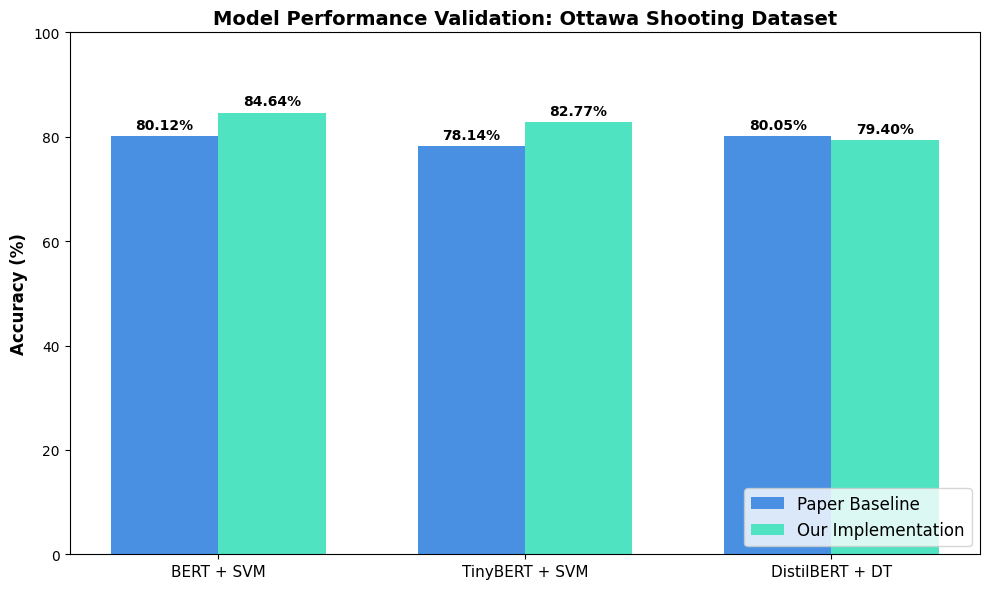

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the data
models = ['BERT + SVM', 'TinyBERT + SVM', 'DistilBERT + DT']
paper_accuracy = [80.12, 78.14, 80.05]
your_accuracy = [84.64, 82.77, 79.40]

# 2. Set up the bar chart positioning
x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, paper_accuracy, width, label='Paper Baseline', color='#4A90E2')
rects2 = ax.bar(x + width/2, your_accuracy, width, label='Our Implementation', color='#50E3C2')

# 4. Add labels, title, and custom x-axis tick labels
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Validation: Ottawa Shooting Dataset', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 100) # Keep Y-axis from 0 to 100 for proper scale
ax.legend(fontsize=12, loc='lower right')

# 5. Attach a text label above each bar displaying its height
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# 6. Render the graph
plt.tight_layout()
plt.show()

Generating Confusion Matrix for BERT + SVM...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


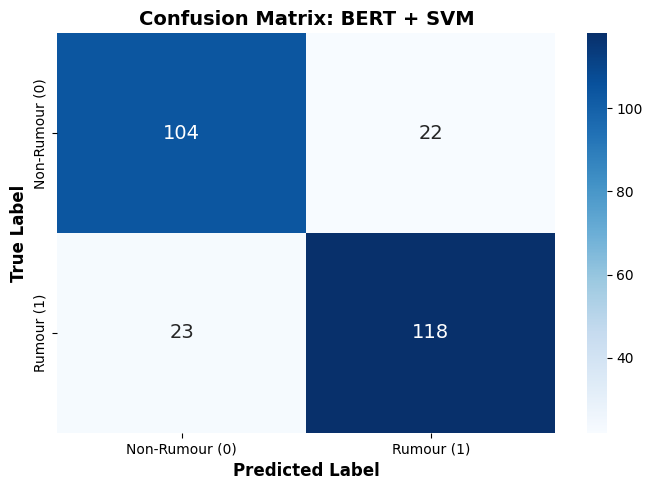

In [38]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_bert_confusion_matrix(model_name, dataframe):
    print("Generating Confusion Matrix for BERT + SVM...")

    # 1. Load Model (Quietly)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to('cuda')
    model.eval()

    def get_embedding(text):
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128).to('cuda')
        with torch.no_grad():
            outputs = model(**inputs)
        return outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

    # 2. Extract Features
    X = np.array([get_embedding(t) for t in dataframe['text']])
    y = dataframe['label'].values

    # 3. PCA & Split
    pca = PCA(n_components=min(X.shape[1], 100))
    X_pca = pca.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

    # 4. Train & Predict
    clf = SVC(kernel='linear', random_state=42)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)

    # 5. Plotting the Confusion Matrix
    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(7, 5))
    # 'Blues' is a great, professional color map for reports
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14},
                xticklabels=['Non-Rumour (0)', 'Rumour (1)'],
                yticklabels=['Non-Rumour (0)', 'Rumour (1)'])

    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.title('Confusion Matrix: BERT + SVM', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Run it! (Make sure your 'df' is still loaded)
plot_bert_confusion_matrix("bert-base-uncased", df)